In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import logistic_regression as LGR
import matplotlib.pyplot as plt

In [2]:
diabetes_dataset = pd.read_csv('./Data/diabetes.csv')

In [3]:
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
diabetes_dataset.shape

(768, 9)

In [5]:
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
diabetes_dataset['Outcome'].value_counts()
# 1 -> Diabetic
# 0 -> non-diabetic

Outcome
0    500
1    268
Name: count, dtype: int64

In [7]:
diabetes_dataset.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [8]:
X = diabetes_dataset.iloc[:, 0:8] # select all rows and columns from 0 to 7
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [9]:
Y = diabetes_dataset.iloc[:, -1:] # select all rows and the last column
Y

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


### Standarization of data
- we do this to so that a single columns dont effect the outcome.
- range of the data is normalized

In [10]:
scalar = StandardScaler()
scalar.fit(X)
X = scalar.transform(X)
X = pd.DataFrame(X)
X

,0,1,2,3,4,5,6,7
0,0.639947,0.848324,0.149641,0.907270,-0.692891,0.204013,0.468492,1.425995
1,-0.844885,-1.123396,-0.160546,0.530902,-0.692891,-0.684422,-0.365061,-0.190672
2,1.233880,1.943724,-0.263941,-1.288212,-0.692891,-1.103255,0.604397,-0.105584
3,-0.844885,-0.998208,-0.160546,0.154533,0.123302,-0.494043,-0.920763,-1.041549
4,-1.141852,0.504055,-1.504687,0.907270,0.765836,1.409746,5.484909,-0.020496
...,...,...,...,...,...,...,...,...
763,1.827813,-0.622642,0.356432,1.722735,0.870031,0.115169,-0.908682,2.532136
764,-0.547919,0.034598,0.046245,0.405445,-0.692891,0.610154,-0.398282,-0.531023
765,0.342981,0.003301,0.149641,0.154533,0.279594,-0.735190,-0.685193,-0.275760
766,-0.844885,0.159787,-0.470732,-1.288212,-0.692891,-0.240205,-0.371101,1.170732


In [11]:
print(type(X))

<class 'pandas.core.frame.DataFrame'>


In [12]:
print(type(Y))

<class 'pandas.core.frame.DataFrame'>


Before passing data into your custom model, convert back to NumPy:

In [13]:
X = X.to_numpy() # ignore this for now
Y = Y.to_numpy().ravel()

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [15]:
print(X.shape,'---> ',X_train.shape,'+',X_test.shape)

(768, 8) --->  (614, 8) + (154, 8)


In [16]:
model = LGR.Logistic_Regression(learning_rate=0.01,no_of_iterations=2500)

In [17]:
model.fit(X_train,Y_train)

In [18]:
weights = model.weights
print(weights)

[ 0.45597657  1.07153446 -0.22202775  0.04164427 -0.09766811  0.62528013
  0.30974896  0.14601409]


In [19]:
bias = model.bias
print(bias)

-0.773115417914513


### Visualization of result

In [20]:
print(dir(model))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', 'bias', 'bias_history', 'cost', 'cost_history', 'fit', 'iterations', 'lr', 'predict', 'sigmoid', 'weight_history', 'weights']


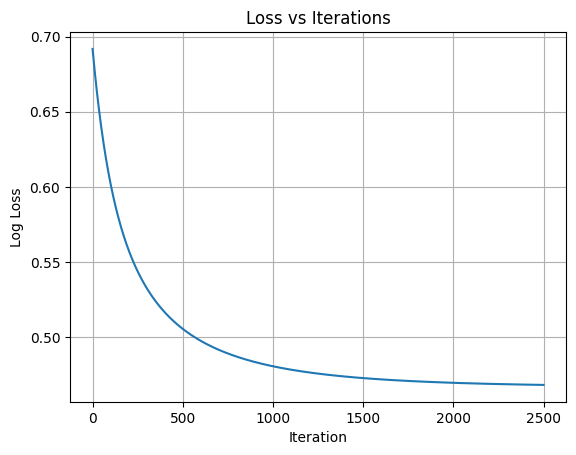

In [21]:
plt.plot(model.cost_history)
plt.title("Loss vs Iterations")
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.grid(True)
plt.show()

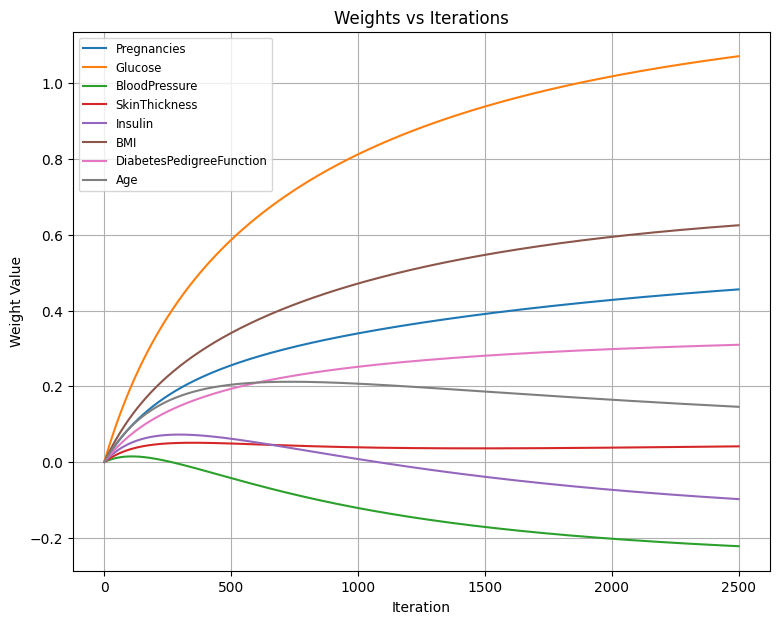

In [30]:

feature_names = diabetes_dataset.drop(columns=['Outcome']).columns
weight_history = np.array(model.weight_history)

plt.figure(figsize=(9,7))

for i in range(weight_history.shape[1]):
    plt.plot(weight_history[:, i], label=feature_names[i])

plt.title("Weights vs Iterations")
plt.xlabel("Iteration")
plt.ylabel("Weight Value")
plt.legend(loc="best", fontsize="small")
plt.grid(True)
plt.show()

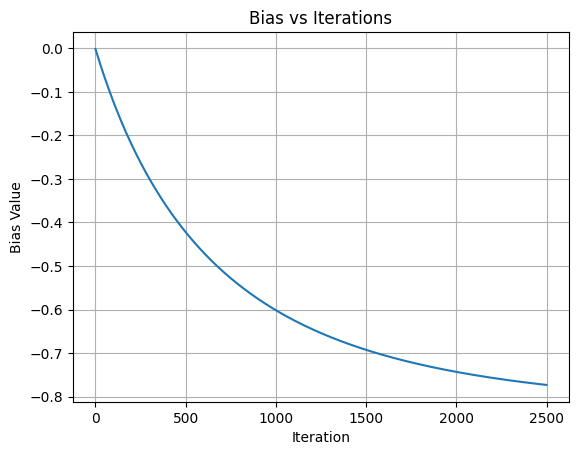

In [23]:
plt.figure()
plt.plot(model.bias_history)
plt.title("Bias vs Iterations")
plt.xlabel("Iteration")
plt.ylabel("Bias Value")
plt.grid(True)
plt.show()

In [118]:
# accuracy score on the training data
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score( Y_train, X_train_prediction)

In [120]:
print('Accuracy score of the training data : ', training_data_accuracy)

Accuracy score of the training data :  0.755700325732899


In [119]:
# accuracy score on the test data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score( Y_test, X_test_prediction)

In [121]:
print('Accuracy score of the test data : ', test_data_accuracy)

Accuracy score of the test data :  0.7402597402597403


### Making a Predictive System by user Input

In [125]:
input_data = (5,166,72,19,175,25.8,0.587,51) # accourding to the labels in diabetes_dataset

# changing the input_data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# standardize the input data
std_data = scalar.transform(input_data_reshaped)
print(std_data)

prediction = model.predict(std_data)
print(prediction)

if (prediction[0] == 0):
  print('The person is not diabetic')
else:
  print('The person is diabetic')

[[  5.    166.     72.     19.    175.     25.8     0.587  51.   ]]
[1]
The person is diabetic
